In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import shap

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),
    Dense(1, activation='sigmoid')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
oil_prob = pd.read_csv('/content/synthetic_oil_data.csv')
print(oil_prob.shape)
oil_prob.head()

(5000, 8)


,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Shale,0.438848,903.714252,NaN,0.181881,4.226811,1547,0
1,Sandstone,6.217269,111.883819,Fault,0.169586,0.583624,4878,0
2,Shale,21.397076,177.944336,NaN,0.862800,0.180588,1815,0
3,Shale,11.598605,429.236160,Dome,0.498148,3.042691,1886,0
4,Sandstone,19.874518,127.586022,Anticline,0.245937,1.708715,4420,0


In [4]:
oil_prob.isna().sum()

,0
Rock_Type,0
Porosity,0
Permeability,0
Trap_Type,1253
Seismic_Score,0
Proximity_to_Oil_Field,0
Estimated_Reservoir_Depth,0
Oil_Presence,0


In [5]:
oil_prob['Trap_Type'].value_counts(dropna=False)

,count
Trap_Type,
Dome,1258
NaN,1253
Fault,1252
Anticline,1237


In [6]:
oil_prob['Trap_Type'] = oil_prob['Trap_Type'].fillna('Unknown')

In [7]:
oil_prob.head()

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Shale,0.438848,903.714252,Unknown,0.181881,4.226811,1547,0
1,Sandstone,6.217269,111.883819,Fault,0.169586,0.583624,4878,0
2,Shale,21.397076,177.944336,Unknown,0.862800,0.180588,1815,0
3,Shale,11.598605,429.236160,Dome,0.498148,3.042691,1886,0
4,Sandstone,19.874518,127.586022,Anticline,0.245937,1.708715,4420,0


In [8]:
scaler = StandardScaler()
oil_prob_scaled = oil_prob.copy()
oil_prob_scaled[['Porosity','Permeability','Seismic_Score','Proximity_to_Oil_Field','Estimated_Reservoir_Depth']] = scaler.fit_transform(oil_prob_scaled[['Porosity','Permeability','Seismic_Score','Proximity_to_Oil_Field','Estimated_Reservoir_Depth']])
oil_prob_scaled.head()

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Shale,-1.673984,1.408658,Unknown,-1.083231,1.178435,-0.934257,0
1,Sandstone,-1.007803,-1.352817,Fault,-1.125948,-1.326879,1.642850,0
2,Shale,0.742242,-1.122434,Unknown,1.282592,-1.604035,-0.726912,0
3,Shale,-0.387402,-0.246065,Dome,0.015627,0.364150,-0.671982,0
4,Sandstone,0.566710,-1.298057,Anticline,-0.860669,-0.553186,1.288508,0


In [9]:
oil_prob_scaled.Rock_Type.value_counts()

,count
Rock_Type,
Sandstone,1738
Limestone,1640
Shale,1622


In [10]:
oil_prob_scaled = pd.get_dummies(oil_prob_scaled, columns=['Rock_Type','Trap_Type'],dtype = int)
oil_prob = pd.get_dummies(oil_prob, columns=['Rock_Type','Trap_Type'],dtype = int)
oil_prob_scaled.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0


In [11]:
oil_prob_scaled.duplicated().sum()

np.int64(0)

In [12]:
oil_prob_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Porosity                   5000 non-null   float64
 1   Permeability               5000 non-null   float64
 2   Seismic_Score              5000 non-null   float64
 3   Proximity_to_Oil_Field     5000 non-null   float64
 4   Estimated_Reservoir_Depth  5000 non-null   float64
 5   Oil_Presence               5000 non-null   int64  
 6   Rock_Type_Limestone        5000 non-null   int64  
 7   Rock_Type_Sandstone        5000 non-null   int64  
 8   Rock_Type_Shale            5000 non-null   int64  
 9   Trap_Type_Anticline        5000 non-null   int64  
 10  Trap_Type_Dome             5000 non-null   int64  
 11  Trap_Type_Fault            5000 non-null   int64  
 12  Trap_Type_Unknown          5000 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 507.9 KB


In [13]:
oil_prob_scaled.describe()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.542233e-17,-1.460165e-16,6.252776e-17,4.831691e-17,-7.389644e-17,0.27760,0.328000,0.347600,0.324400,0.247400,0.251600,0.250400,0.250600
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,0.44786,0.469532,0.476256,0.468197,0.431544,0.433976,0.433287,0.433402
min,-1.723933e+00,-1.739107e+00,-1.715135e+00,-1.727528e+00,-1.744293e+00,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.527967e-01,-8.448278e-01,-8.647310e-01,-8.635557e-01,-8.514739e-01,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.106790e-02,2.828639e-03,-6.976181e-03,-1.507543e-02,-7.782694e-03,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.625043e-01,8.541223e-01,8.593627e-01,8.776071e-01,8.608595e-01,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.733532e+00,1.743431e+00,1.758227e+00,1.709523e+00,1.734917e+00,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
oil_prob_scaled.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0


In [15]:
oil_prob_scaled['Oil_Presence'].value_counts()

,count
Oil_Presence,
0,3612
1,1388


In [16]:
correlation=oil_prob_scaled.corr()

<Axes: >

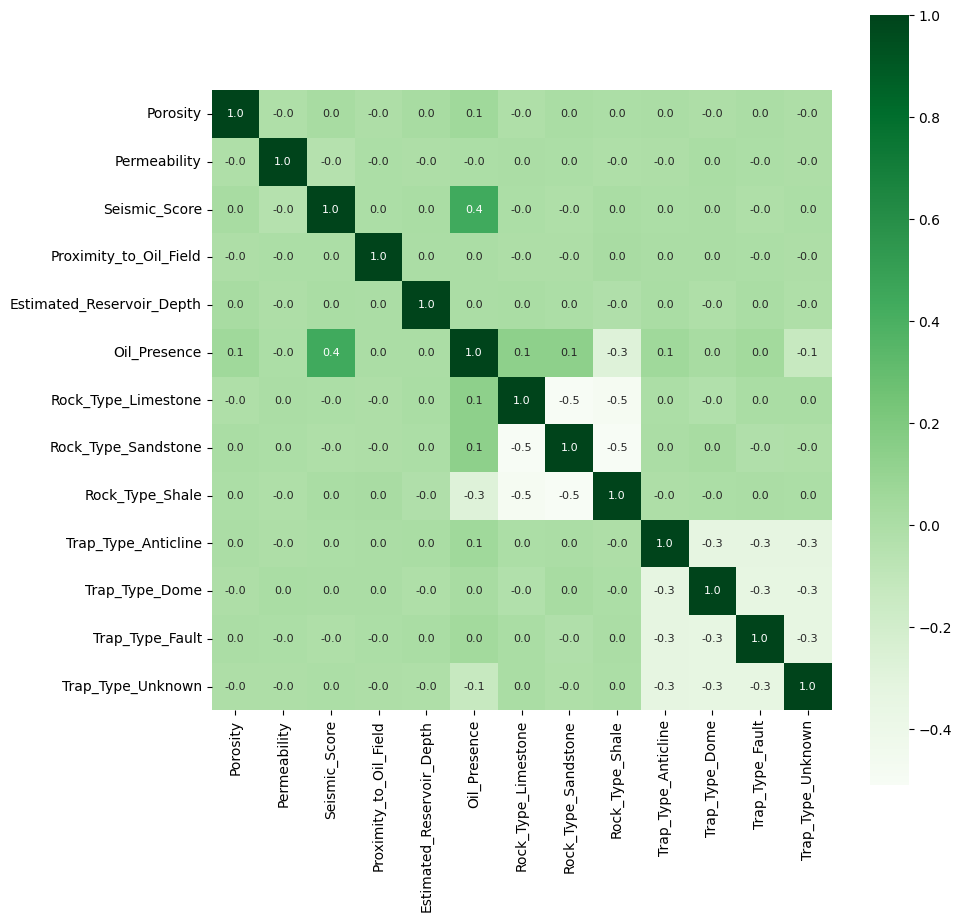

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar = True,square=True,fmt = '.1f',annot = True,annot_kws={'size' : 8},cmap='Greens')

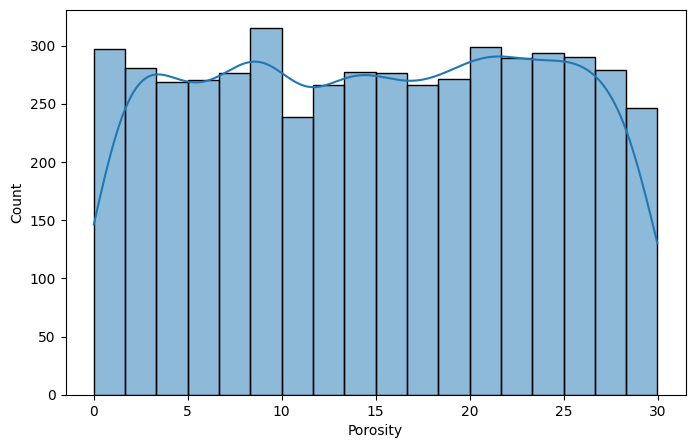

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(oil_prob1["Porosity"], kde=True)

plt.show()

In [19]:
oil_prob1 = pd.read_csv('/content/synthetic_oil_data.csv')
oil_prob1['Trap_Type'] = oil_prob1['Trap_Type'].fillna('Unknown')
oil_prob1.head()

,Rock_Type,Porosity,Permeability,Trap_Type,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence
0,Shale,0.438848,903.714252,Unknown,0.181881,4.226811,1547,0
1,Sandstone,6.217269,111.883819,Fault,0.169586,0.583624,4878,0
2,Shale,21.397076,177.944336,Unknown,0.862800,0.180588,1815,0
3,Shale,11.598605,429.236160,Dome,0.498148,3.042691,1886,0
4,Sandstone,19.874518,127.586022,Anticline,0.245937,1.708715,4420,0


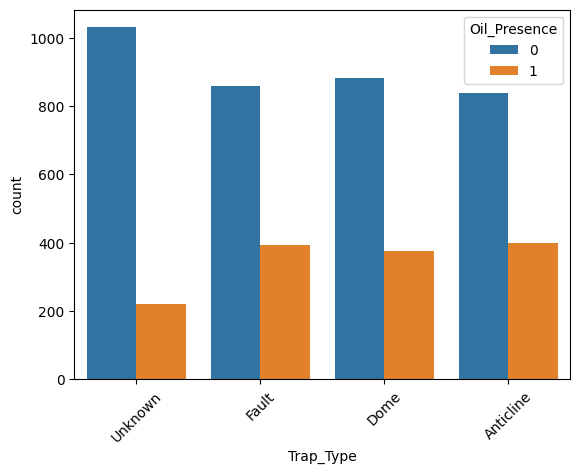

In [21]:
sns.countplot(x="Trap_Type",
              hue="Oil_Presence",
              data=oil_prob1)

plt.xticks(rotation=45)

plt.show()

In [22]:
def reservoir_quality(row):
    if row["Porosity"] >= 20 and row["Permeability"] >= 300:
        return "Excellent"
    elif row["Porosity"] >= 15 and row["Permeability"] >= 150:
        return "Good"
    elif row["Porosity"] >= 10 and row["Permeability"] >= 50:
        return "Average"
    else:
        return "Poor"

oil_prob["Reservoir_Quality"] = oil_prob.apply(reservoir_quality, axis=1)
oil_prob_scaled["Reservoir_Quality"] = oil_prob.apply(reservoir_quality, axis=1)
oil_prob.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Reservoir_Quality
0,0.438848,903.714252,0.181881,4.226811,1547,0,0,0,1,0,0,0,1,Poor
1,6.217269,111.883819,0.169586,0.583624,4878,0,0,1,0,0,0,1,0,Poor
2,21.397076,177.944336,0.862800,0.180588,1815,0,0,0,1,0,0,0,1,Good
3,11.598605,429.236160,0.498148,3.042691,1886,0,0,0,1,0,1,0,0,Average
4,19.874518,127.586022,0.245937,1.708715,4420,0,0,1,0,1,0,0,0,Average


In [23]:
oil_prob["Pore_Connectivity_Index"] = np.sqrt(
    oil_prob["Porosity"] * oil_prob["Permeability"]
)
oil_prob["Reservoir_Flow_Capacity"] = (
    oil_prob["Permeability"] *
    oil_prob["Porosity"]
) / oil_prob["Estimated_Reservoir_Depth"]

perm = oil_prob["Permeability"] / oil_prob["Permeability"].max()
poro = oil_prob["Porosity"] / oil_prob["Porosity"].max()

oil_prob["Hydrocarbon_Prospect_Score"] = (
    0.35 * poro +
    0.35 * perm +
    0.30 * oil_prob["Seismic_Score"]
)
oil_prob_scaled["Pore_Connectivity_Index"] = np.sqrt(
    oil_prob["Porosity"] * oil_prob["Permeability"]
)
oil_prob_scaled["Reservoir_Flow_Capacity"] = (
    oil_prob["Permeability"] *
    oil_prob["Porosity"]
) / oil_prob["Estimated_Reservoir_Depth"]

perm = oil_prob["Permeability"] / oil_prob["Permeability"].max()
poro = oil_prob["Porosity"] / oil_prob["Porosity"].max()

oil_prob_scaled["Hydrocarbon_Prospect_Score"] = (
    0.35 * poro +
    0.35 * perm +
    0.30 * oil_prob["Seismic_Score"]
)


In [24]:
oil_prob["Porosity"].max()

29.995477334592007

In [25]:
oil_prob.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Reservoir_Quality,Pore_Connectivity_Index,Reservoir_Flow_Capacity,Hydrocarbon_Prospect_Score
0,0.438848,903.714252,0.181881,4.226811,1547,0,0,0,1,0,0,0,1,Poor,19.914642,0.256363,0.376077
1,6.217269,111.883819,0.169586,0.583624,4878,0,0,1,0,0,0,1,0,Poor,26.374454,0.142602,0.162592
2,21.397076,177.944336,0.862800,0.180588,1815,0,0,0,1,0,0,0,1,Good,61.704850,2.097790,0.570809
3,11.598605,429.236160,0.498148,3.042691,1886,0,0,0,1,0,1,0,0,Average,70.558775,2.639735,0.435059
4,19.874518,127.586022,0.245937,1.708715,4420,0,0,1,0,1,0,0,0,Average,50.355841,0.573690,0.350354


In [26]:
oil_prob_scaled

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Reservoir_Quality,Pore_Connectivity_Index,Reservoir_Flow_Capacity,Hydrocarbon_Prospect_Score
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1,Poor,19.914642,0.256363,0.376077
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0,Poor,26.374454,0.142602,0.162592
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1,Good,61.704850,2.097790,0.570809
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0,Average,70.558775,2.639735,0.435059
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0,Average,50.355841,0.573690,0.350354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.736868,-0.528755,1.122150,0.986618,-0.897121,1,0,1,0,0,0,1,0,Excellent,86.219121,4.660650,0.616010
4996,-0.995058,-0.592879,-0.098459,-0.666199,0.035156,1,1,0,0,0,0,0,1,Poor,45.682075,0.745304,0.328890
4997,0.601429,0.251355,1.475756,0.904152,1.343438,0,0,0,1,0,0,0,1,Excellent,107.414177,2.569095,0.711149
4998,0.711194,-0.884199,1.026693,1.520314,-1.347399,1,1,0,0,1,0,0,0,Good,72.130765,5.136078,0.569487


In [27]:
oil_prob_scaled[['Pore_Connectivity_Index','Reservoir_Flow_Capacity','Hydrocarbon_Prospect_Score']] = scaler.fit_transform(oil_prob_scaled[['Pore_Connectivity_Index','Reservoir_Flow_Capacity','Hydrocarbon_Prospect_Score']])
oil_prob_scaled.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Reservoir_Quality,Pore_Connectivity_Index,Reservoir_Flow_Capacity,Hydrocarbon_Prospect_Score
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1,Poor,-1.439910,-0.744085,-0.734425
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0,Poor,-1.276326,-0.768448,-2.024404
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1,Good,-0.381638,-0.349731,0.442238
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0,Average,-0.157427,-0.233669,-0.378032
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0,Average,-0.669034,-0.676128,-0.889859


In [28]:
oil_prob['Reservoir_Quality'].value_counts()

,count
Reservoir_Quality,
Poor,1867
Excellent,1188
Average,986
Good,959


In [29]:
oil_prob_scaled = pd.get_dummies(oil_prob_scaled, columns=['Reservoir_Quality'],dtype = int)
oil_prob = pd.get_dummies(oil_prob, columns=['Reservoir_Quality'],dtype = int)
oil_prob_scaled.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Pore_Connectivity_Index,Reservoir_Flow_Capacity,Hydrocarbon_Prospect_Score,Reservoir_Quality_Average,Reservoir_Quality_Excellent,Reservoir_Quality_Good,Reservoir_Quality_Poor
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1,-1.439910,-0.744085,-0.734425,0,0,0,1
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0,-1.276326,-0.768448,-2.024404,0,0,0,1
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1,-0.381638,-0.349731,0.442238,0,0,1,0
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0,-0.157427,-0.233669,-0.378032,1,0,0,0
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0,-0.669034,-0.676128,-0.889859,1,0,0,0


<Axes: >

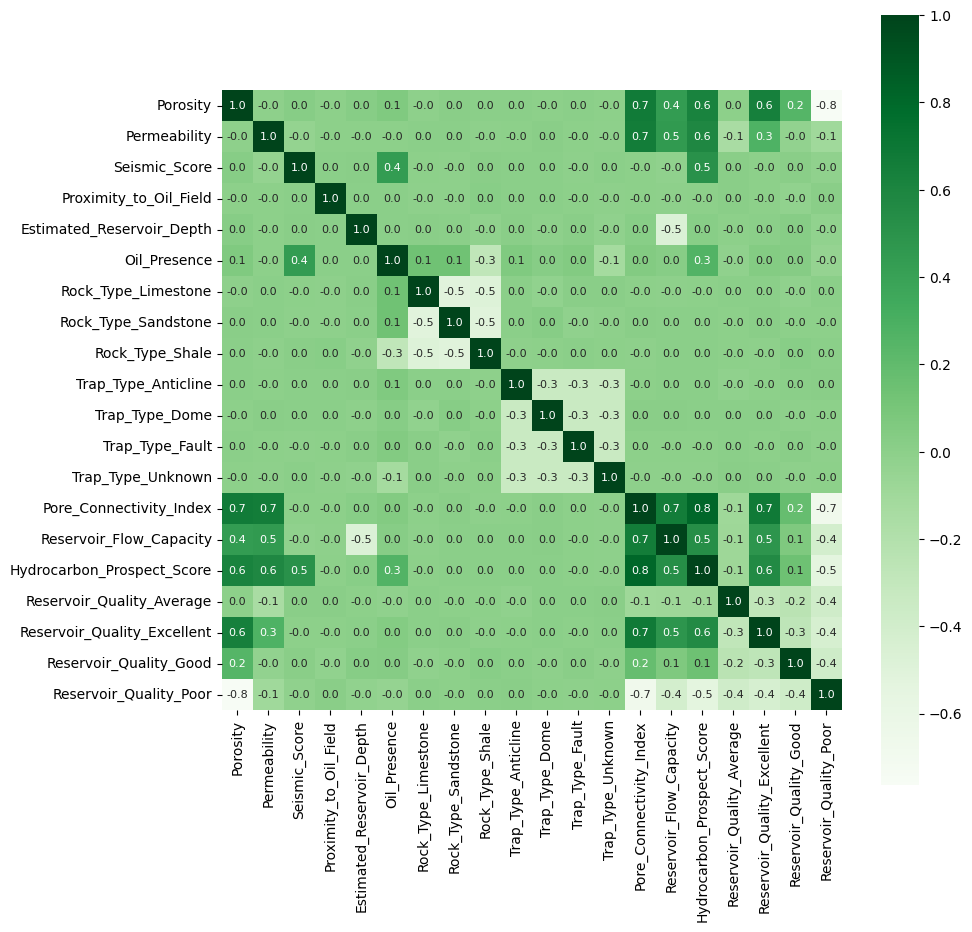

In [30]:
correlation = oil_prob_scaled.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar = True,square=True,fmt = '.1f',annot = True,annot_kws={'size' : 8},cmap='Greens')

In [31]:
corr_target = correlation["Oil_Presence"].sort_values(ascending=False)

print(corr_target)

Oil_Presence                   1.000000
Seismic_Score                  0.438554
Hydrocarbon_Prospect_Score     0.263328
Rock_Type_Limestone            0.138636
Rock_Type_Sandstone            0.134611
Porosity                       0.058804
Trap_Type_Anticline            0.057556
Trap_Type_Fault                0.045816
Pore_Connectivity_Index        0.042955
Reservoir_Quality_Excellent    0.035899
Reservoir_Quality_Good         0.031514
Reservoir_Flow_Capacity        0.028452
Trap_Type_Dome                 0.026533
Estimated_Reservoir_Depth      0.007324
Proximity_to_Oil_Field         0.003533
Permeability                  -0.002380
Reservoir_Quality_Average     -0.018760
Reservoir_Quality_Poor        -0.041807
Trap_Type_Unknown             -0.129681
Rock_Type_Shale               -0.275959
Name: Oil_Presence, dtype: float64


In [32]:
from sklearn.feature_selection import mutual_info_classif

X = oil_prob.drop("Oil_Presence", axis=1)
y = oil_prob["Oil_Presence"]

mi = mutual_info_classif(X, y, random_state=42)

mi = pd.Series(mi, index=X.columns)

mi.sort_values(ascending=False)

,0
Seismic_Score,0.131582
Hydrocarbon_Prospect_Score,0.040794
Rock_Type_Shale,0.039200
Trap_Type_Unknown,0.020035
Rock_Type_Limestone,0.009925
Reservoir_Quality_Good,0.009911
Reservoir_Quality_Excellent,0.009841
Rock_Type_Sandstone,0.006342
Trap_Type_Fault,0.006243
Trap_Type_Dome,0.003063


In [33]:
X = oil_prob.drop("Oil_Presence", axis=1)
Y = oil_prob["Oil_Presence"]
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)


In [34]:
x = oil_prob_scaled.drop("Oil_Presence",axis = 1)
y = oil_prob_scaled["Oil_Presence"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42,stratify=y)

In [35]:
def evaluate_model(model,X_Train,Y_Train,X_Test,Y_Test):
  model.fit(X_Train,Y_Train)
  y_pred = model.predict(X_Test)
  y_prob = model.predict_proba(X_Test)[:,1]

  print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
  print(f"Precision: {precision_score(y_test,y_pred):.4f}")
  print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
  print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
  print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

  print("CLASSIFICATION REPORTS")
  print(classification_report(y_test,y_pred))

  print("CONFUSION MATRIX")
  print(confusion_matrix(y_test,y_pred))

  return {
      "accuracy" : accuracy_score(y_test,y_pred),
      "precision" : precision_score(y_test,y_pred),
      "recall" : recall_score(y_test,y_pred),
      "F1 Score" : f1_score(y_test,y_pred),
      "ROC AUC" : roc_auc_score(y_test,y_prob)
  }

In [36]:
def evaluate_model_scaled(model,x_train,y_train,x_test,y_test):
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  y_prob = model.predict_proba(x_test)[:,1]

  print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
  print(f"Precision: {precision_score(y_test,y_pred):.4f}")
  print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
  print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
  print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

  print("CLASSIFICATION REPORTS")
  print(classification_report(y_test,y_pred))

  print("CONFUSION MATRIX")
  print(confusion_matrix(y_test,y_pred))

  return {
      "accuracy" : accuracy_score(y_test,y_pred),
      "precision" : precision_score(y_test,y_pred),
      "recall" : recall_score(y_test,y_pred),
      "F1 Score" : f1_score(y_test,y_pred),
      "ROC AUC" : roc_auc_score(y_test,y_prob)
  }

In [37]:
lr = LogisticRegression()
xgb = XGBClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [38]:
lr_results = evaluate_model_scaled(lr,x_train,y_train,x_test,y_test)
xgb_results = evaluate_model(xgb,X_Train,Y_Train,X_Test,Y_Test)
dt_results = evaluate_model(dt,X_Train,Y_Train,X_Test,Y_Test)
rf_results = evaluate_model(rf,X_Train,Y_Train,X_Test,Y_Test)


Accuracy : 0.8910
Precision: 0.8722
Recall   : 0.7122
F1 Score : 0.7842
ROC AUC  : 0.8647
CLASSIFICATION REPORTS
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       722
           1       0.87      0.71      0.78       278

    accuracy                           0.89      1000
   macro avg       0.88      0.84      0.86      1000
weighted avg       0.89      0.89      0.89      1000

CONFUSION MATRIX
[[693  29]
 [ 80 198]]
Accuracy : 0.9040
Precision: 0.8991
Recall   : 0.7374
F1 Score : 0.8103
ROC AUC  : 0.8685
CLASSIFICATION REPORTS
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       722
           1       0.90      0.74      0.81       278

    accuracy                           0.90      1000
   macro avg       0.90      0.85      0.87      1000
weighted avg       0.90      0.90      0.90      1000

CONFUSION MATRIX
[[699  23]
 [ 73 205]]
Accuracy : 0.8100
Precision: 0.6560
Reca

In [39]:
comparison = pd.DataFrame({
    "Logistic Regression":lr_results,
    "Decision Tree":dt_results,
    "Random Forest":rf_results,
    "XGBoost":xgb_results
}).T

comparison

,accuracy,precision,recall,F1 Score,ROC AUC
Logistic Regression,0.891,0.872247,0.712230,0.784158,0.864674
Decision Tree,0.810,0.656028,0.665468,0.660714,0.765559
Random Forest,0.909,0.919283,0.737410,0.818363,0.868095
XGBoost,0.904,0.899123,0.737410,0.810277,0.868451


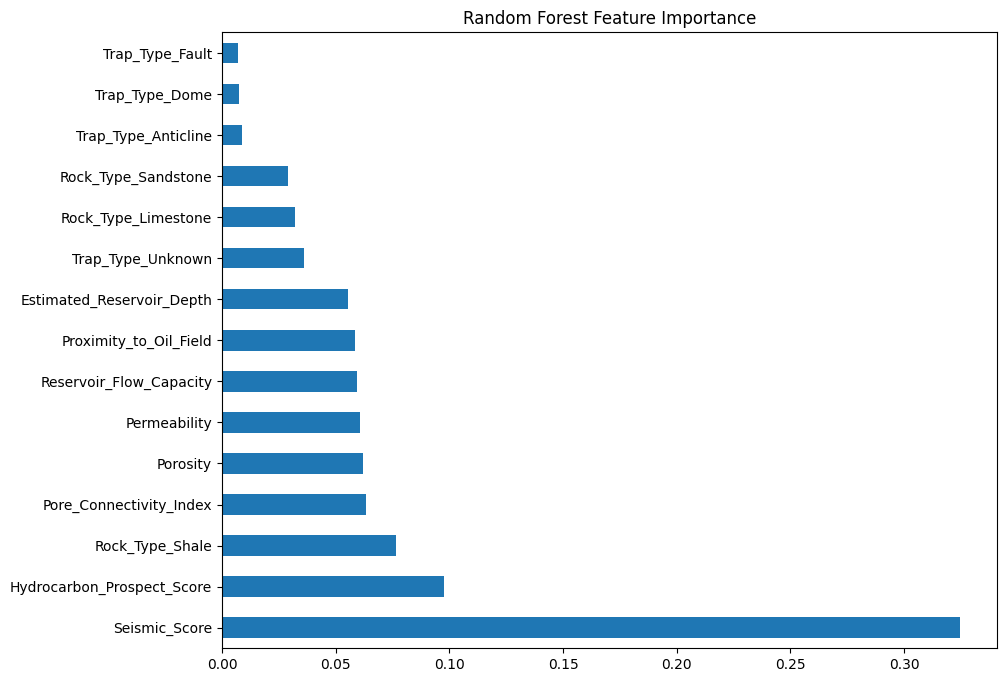

In [40]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_Train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.head(15).plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.show()

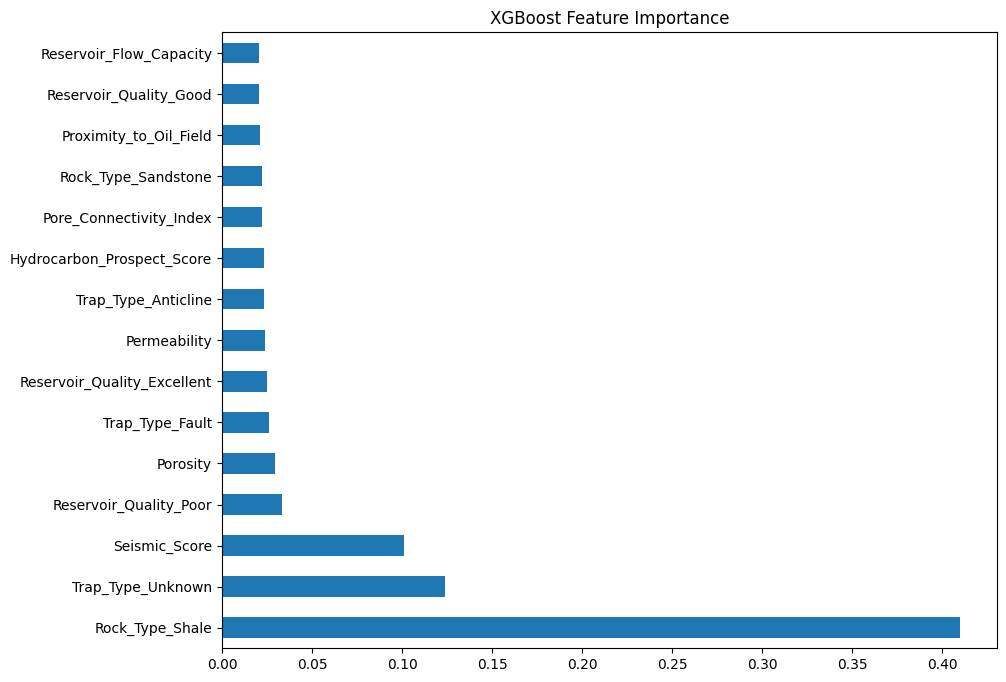

In [41]:
importances = pd.Series(
    xgb.feature_importances_,
    index=X_Train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.head(15).plot(kind='barh')

plt.title("XGBoost Feature Importance")
plt.show()

In [42]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [10,20,30,35],
    'max_depth': [ 10,20,30],
    "min_samples_split" : [2,4],
    "min_samples_leaf" : [2,3],
    "max_features" : ['sqrt'],
    "bootstrap": [True]}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring = "f1"
)

random_search.fit(X_Train, Y_Train)
print(f"Best hyperparameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")
best_rf = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'n_estimators': 35, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True}
Best score: 0.7963034646677561


In [43]:
rf_tuned_results = evaluate_model(
    best_rf,
    X_Train,
   Y_Train,
    X_Test,
    Y_Test
)

Accuracy : 0.9070
Precision: 0.9111
Recall   : 0.7374
F1 Score : 0.8151
ROC AUC  : 0.8665
CLASSIFICATION REPORTS
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       722
           1       0.91      0.74      0.82       278

    accuracy                           0.91      1000
   macro avg       0.91      0.85      0.88      1000
weighted avg       0.91      0.91      0.90      1000

CONFUSION MATRIX
[[702  20]
 [ 73 205]]


In [44]:
xgb_params = {
    "n_estimators": [10,20,30,40],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_Train, Y_Train)

print(f"Best hyperparameters: {xgb_random.best_params_}")
best_xgb = xgb_random.best_estimator_



Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'subsample': 0.8, 'n_estimators': 30, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [45]:
xgb_tuned_results = evaluate_model(
    best_xgb,
    X_Train,
   Y_Train,
    X_Test,
    Y_Test
)

Accuracy : 0.9110
Precision: 0.9276
Recall   : 0.7374
F1 Score : 0.8216
ROC AUC  : 0.8781
CLASSIFICATION REPORTS
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       722
           1       0.93      0.74      0.82       278

    accuracy                           0.91      1000
   macro avg       0.92      0.86      0.88      1000
weighted avg       0.91      0.91      0.91      1000

CONFUSION MATRIX
[[706  16]
 [ 73 205]]


In [46]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])



In [47]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy',
               tf.keras.metrics.Precision(),
               tf.keras.metrics.Recall(),
               tf.keras.metrics.AUC()]
)

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience = 5)

In [49]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1

)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7400 - auc: 0.7208 - loss: 0.5434 - precision: 0.5714 - recall: 0.2523 - val_accuracy: 0.8090 - val_auc: 0.8240 - val_loss: 0.5452 - val_precision: 0.6916 - val_recall: 0.5647 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8023 - auc: 0.7946 - loss: 0.4747 - precision: 0.6972 - recall: 0.5081 - val_accuracy: 0.8740 - val_auc: 0.8556 - val_loss: 0.4315 - val_precision: 0.8167 - val_recall: 0.7050 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8342 - auc: 0.8272 - loss: 0.4307 - precision: 0.7722 - recall: 0.5712 - val_accuracy: 0.8830 - val_auc: 0.8636 - val_loss: 0.3629 - val_precision: 0.8233 - val_recall: 0.7374 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8478 - auc: 0.8391 - loss: 0.4058 - precision: 0.7805 - recall: 0.6279 - val_accuracy: 0.8950 - val_auc: 0.8650 - val_loss: 0.3445 

In [50]:
loss, accuracy, precision, recall, auc = model.evaluate(x_test, y_test)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC AUC  : {auc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8980 - auc: 0.8778 - loss: 0.3153 - precision: 0.8860 - recall: 0.7266
Accuracy : 0.8980
Precision: 0.8860
Recall   : 0.7266
ROC AUC  : 0.8778


In [51]:
y_prob = model.predict(x_test)
y_pred = (y_prob>0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [52]:
y_pred = y_pred.ravel()
print(y_pred)

[1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1 0 0 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0
 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0 0 1 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 0 

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.898
Precision: 0.8859649122807017
Recall   : 0.7266187050359713
F1 Score : 0.7984189723320159
ROC AUC  : 0.8774537156978017

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       722
           1       0.89      0.73      0.80       278

    accuracy                           0.90      1000
   macro avg       0.89      0.85      0.87      1000
weighted avg       0.90      0.90      0.89      1000


Confusion Matrix
[[696  26]
 [ 76 202]]


In [54]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(0.6920415224913494), 1: np.float64(1.8018018018018018)}


In [55]:
Model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [56]:
Model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy',
               tf.keras.metrics.Precision(name ="precision"),
               tf.keras.metrics.Recall(name = "recall"),
               tf.keras.metrics.AUC(name = "auc")]
)

In [57]:
Early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

Reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience = 5,
    verbose=1
)


In [58]:
History = Model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[Early_stop, Reduce_lr],
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6334 - auc: 0.7500 - loss: 0.6080 - precision: 0.4172 - recall: 0.7717 - val_accuracy: 0.8612 - val_auc: 0.8321 - val_loss: 0.4678 - val_precision: 0.8176 - val_recall: 0.6132 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7894 - auc: 0.8167 - loss: 0.5173 - precision: 0.6057 - recall: 0.7149 - val_accuracy: 0.8625 - val_auc: 0.8270 - val_loss: 0.4468 - val_precision: 0.7383 - val_recall: 0.7453 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8000 - auc: 0.8226 - loss: 0.5061 - precision: 0.6243 - recall: 0.7216 - val_accuracy: 0.8475 - val_auc: 0.8437 - val_loss: 0.4332 - val_precision: 0.6991 - val_recall: 0.7453 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8184 - auc: 0.8307 - loss: 0.4872 - precision: 0.6646 - recall: 0.7127 - val_accuracy: 0.8662 - val_auc: 0.8379 - val_loss: 0.4307 -

In [59]:
loss, accuracy, precision, recall, auc = Model.evaluate(
    x_test,
    y_test
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"ROC AUC  : {auc:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8860 - auc: 0.8531 - loss: 0.3749 - precision: 0.8280 - recall: 0.7446
Accuracy : 0.8860
Precision: 0.8280
Recall   : 0.7446
ROC AUC  : 0.8531


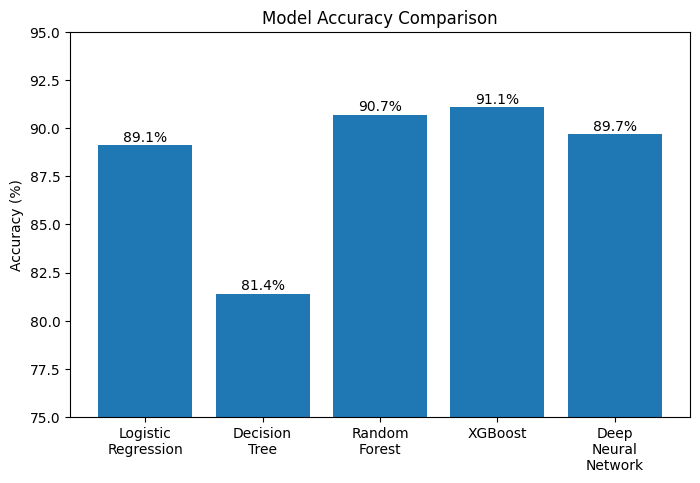

In [60]:
models = [
    "Logistic\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "XGBoost",
    "Deep\nNeural\nNetwork"
]

accuracy = [89.1, 81.4, 90.7, 91.1, 89.7]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.1f}%",
        ha='center'
    )

plt.ylim(75,95)

plt.show()

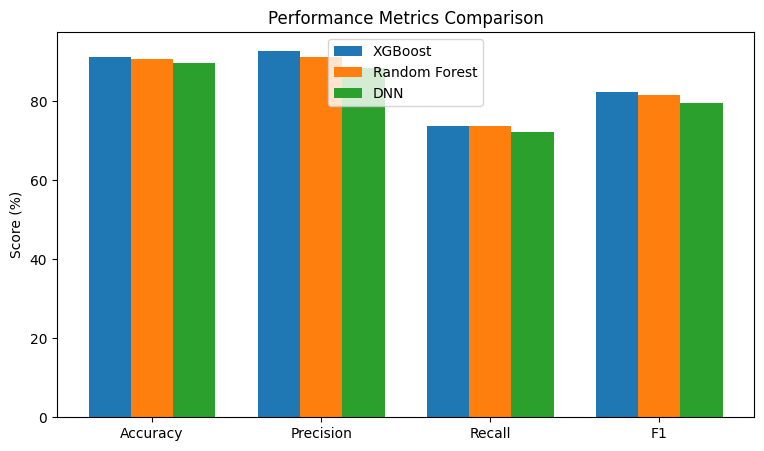

In [61]:
metrics = ["Accuracy","Precision","Recall","F1"]

xgb = [91.1,92.8,73.7,82.2]
rf = [90.7,91.1,73.7,81.5]
dnn = [89.7,88.5,72.3,79.6]

x = np.arange(len(metrics))

width = 0.25

plt.figure(figsize=(9,5))

plt.bar(x-width,xgb,width,label="XGBoost")
plt.bar(x,rf,width,label="Random Forest")
plt.bar(x+width,dnn,width,label="DNN")

plt.xticks(x,metrics)

plt.ylabel("Score (%)")

plt.title("Performance Metrics Comparison")

plt.legend()

plt.show()

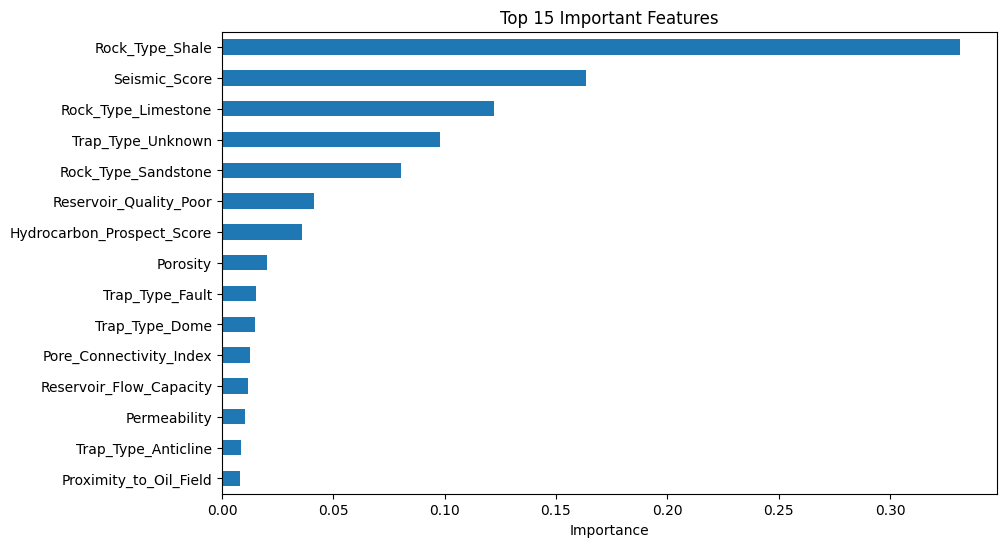

In [62]:
importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_Train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

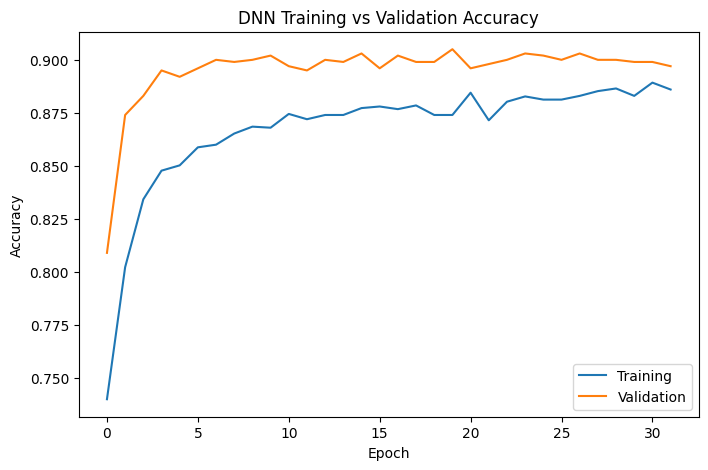

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("DNN Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

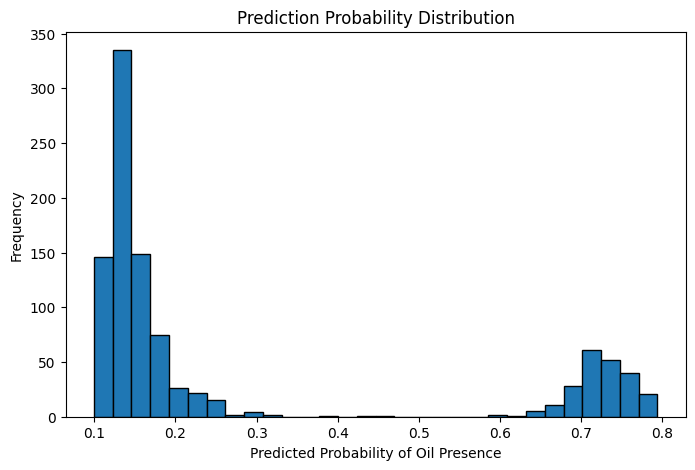

In [64]:
y_prob = best_xgb.predict_proba(X_Test)[:,1]

plt.figure(figsize=(8,5))

plt.hist(
    y_prob,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Predicted Probability of Oil Presence")

plt.ylabel("Frequency")

plt.title("Prediction Probability Distribution")

plt.show()

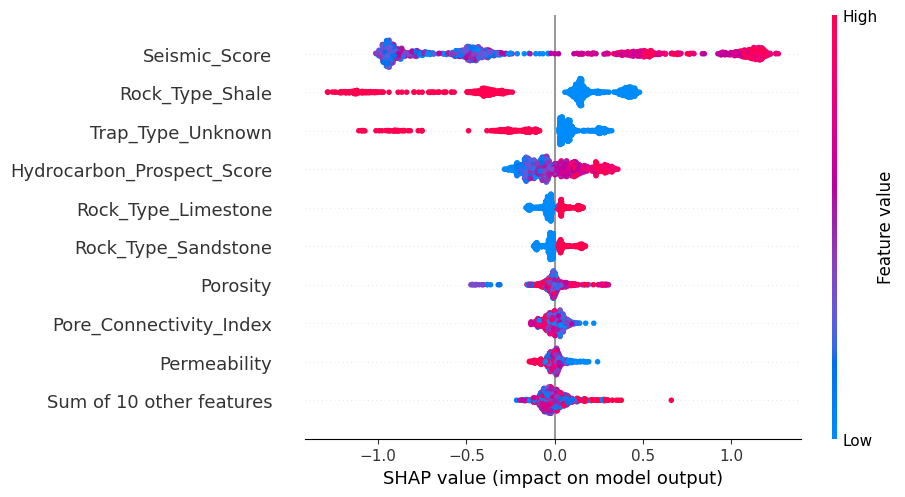

In [65]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer(X_Test)
shap.plots.beeswarm(shap_values)

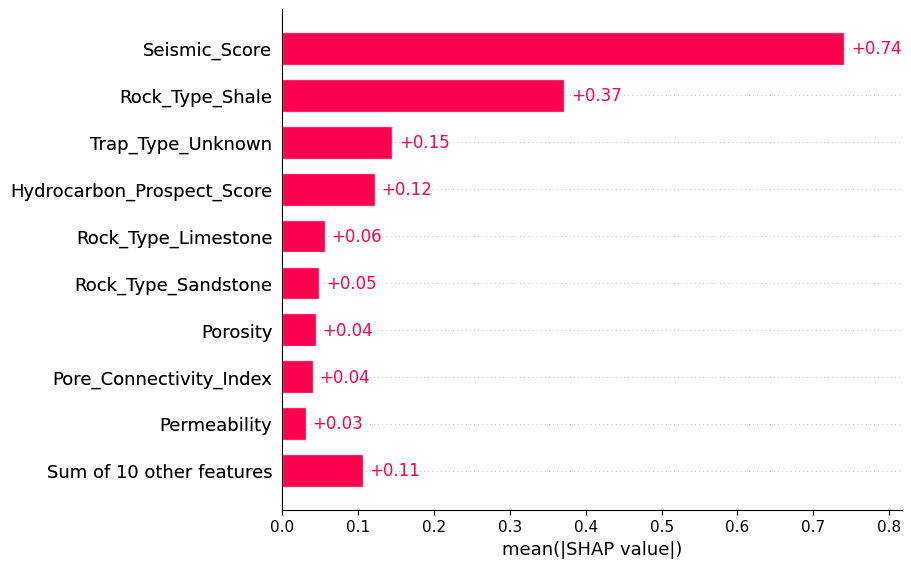

In [66]:
shap.plots.bar(shap_values)

In [67]:
import pickle as pkl
pkl.dump(best_xgb,open('oil_prob_xgb.pkl','wb'))

In [68]:
pkl.dump(scaler,open('scaler.pkl','wb'))

In [69]:
feature_columns = X_Train.columns.tolist()
pkl.dump(feature_columns,open('feature_columns.pkl','wb'))

In [70]:
import os
print(os.path.getsize("oil_prob_xgb.pkl") / (1024 * 1024))

0.08225440979003906


In [71]:
import pickle

with open("oil_prob_xgb.pkl", "rb") as f:
    test_model = pickle.load(f)

print(type(test_model))
print(test_model)

<class 'xgboost.sklearn.XGBClassifier'>
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=30, n_jobs=None,
              num_parallel_tree=None, ...)


In [72]:
from google.colab import files
files.download("oil_prob_xgb.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
import pickle

with open("oil_prob_xgb.pkl", "rb") as f:
    model = pickle.load(f)

print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'xgboost.sklearn.XGBClassifier'>


In [74]:
best_xgb.save_model("oil_prob_xgb.json")

In [75]:
oil_prob_scaled.head()

,Porosity,Permeability,Seismic_Score,Proximity_to_Oil_Field,Estimated_Reservoir_Depth,Oil_Presence,Rock_Type_Limestone,Rock_Type_Sandstone,Rock_Type_Shale,Trap_Type_Anticline,Trap_Type_Dome,Trap_Type_Fault,Trap_Type_Unknown,Pore_Connectivity_Index,Reservoir_Flow_Capacity,Hydrocarbon_Prospect_Score,Reservoir_Quality_Average,Reservoir_Quality_Excellent,Reservoir_Quality_Good,Reservoir_Quality_Poor
0,-1.673984,1.408658,-1.083231,1.178435,-0.934257,0,0,0,1,0,0,0,1,-1.439910,-0.744085,-0.734425,0,0,0,1
1,-1.007803,-1.352817,-1.125948,-1.326879,1.642850,0,0,1,0,0,0,1,0,-1.276326,-0.768448,-2.024404,0,0,0,1
2,0.742242,-1.122434,1.282592,-1.604035,-0.726912,0,0,0,1,0,0,0,1,-0.381638,-0.349731,0.442238,0,0,1,0
3,-0.387402,-0.246065,0.015627,0.364150,-0.671982,0,0,0,1,0,1,0,0,-0.157427,-0.233669,-0.378032,1,0,0,0
4,0.566710,-1.298057,-0.860669,-0.553186,1.288508,0,0,1,0,1,0,0,0,-0.669034,-0.676128,-0.889859,1,0,0,0


In [78]:
print(scaler.feature_names_in_)


['Pore_Connectivity_Index' 'Reservoir_Flow_Capacity'
 'Hydrocarbon_Prospect_Score']
